# Лабораторная номер 2 по анализу данных на Python

## Импорты 

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## Загружаем данные

In [5]:
# Загружаем данные с помощью pandas метода read_csv
df = pd.read_csv("data/Econom_Cities_data.csv", sep=";")

# Смотрим на данные 
df.head(5)

,City,Work,Price,Salary
0,Amsterdam,1714,"65,6",49
1,Athens,1792,"53,8","30,4"
2,Bogota,2152,"37,9","11,5"
3,Bombay,2052,"30,3","5,3"
4,Brussels,1708,"73,8","50,5"


In [6]:
# типы данных для каждого столбца
# только Work имеет числовой тип int64
df.dtypes

City      object
Work       int64
Price     object
Salary    object
dtype: object

In [7]:
assert len(df["City"].unique()) == len(df)  # Все города уникальны

Так как города уникальны, можно установить колонку City в качестве индекса нашего pandas датафрейма.

In [9]:
# Устанавливаем индексом колонку "City"
df = df.set_index("City")

## Предобработка данных

Преобразуем колонки Price и Salary, чтобы их тип был float64.

In [12]:
df["Price"] = (df["Price"].apply(lambda x: x.replace(",", "."))).astype(float)
df["Salary"] = (df["Salary"].apply(lambda x: x.replace(",", "."))).astype(float)

In [13]:
# типы данных для всех колонок
df.dtypes

Work        int64
Price     float64
Salary    float64
dtype: object

Также, так как из первой лабораторной мы знаем, что Cairo и Jakarta — это выбросы, мы удаляем их из нашего датафрейма.

In [15]:
df.loc[["Cairo", "Jakarta"]]

,Work,Price,Salary
City,,,
Cairo,-9999,37.1,-9999.0
Jakarta,-9999,43.6,-9999.0


In [16]:
# Убираем из нашего pandas датафрейма Каир и Джакарту
df = df.loc[~df.index.isin(["Cairo", "Jakarta"])]

Так как наши признаки имеют разный масштаб (например, значения признака Work по наблюдениям сильно больше значений признака Salary), нам надо стандартизировать их.

Для этого мы импортируем StandardScaler из sklearn и стандартизуем данные. 

In [18]:
# Для стандартизации используем StandardScaler из scikit-learn
standard_scaler = StandardScaler()

# Записываем стандартизованные данные тоже в pandas.DataFrame с тем же индексом и теми же названиями колонок
df_scaled = pd.DataFrame(standard_scaler.fit_transform(df.values), index=df.index, columns=df.columns)

## Применяем метод K-means

Попробуем определить число кластеров не угадывая.

In [21]:
# у нас всего 48 городов, так что попробуем кол-во кластеров поставить от 1 до 10
K = range(1, 11) 

# Максимальное кол-во итераций алгоритму, чтобы сойтись
init_max_iter = 500

# Кластеризуем KMeans с разными k
models = [KMeans(n_clusters=k, random_state=42, n_init=100, max_iter=init_max_iter, verbose=0).fit(df_scaled) for k in K]

# Сумма квадратов расстояний точек от центроида для каждого кластера
dist = [model.inertia_ for model in models]

Строим график **каменистая осыпь**.

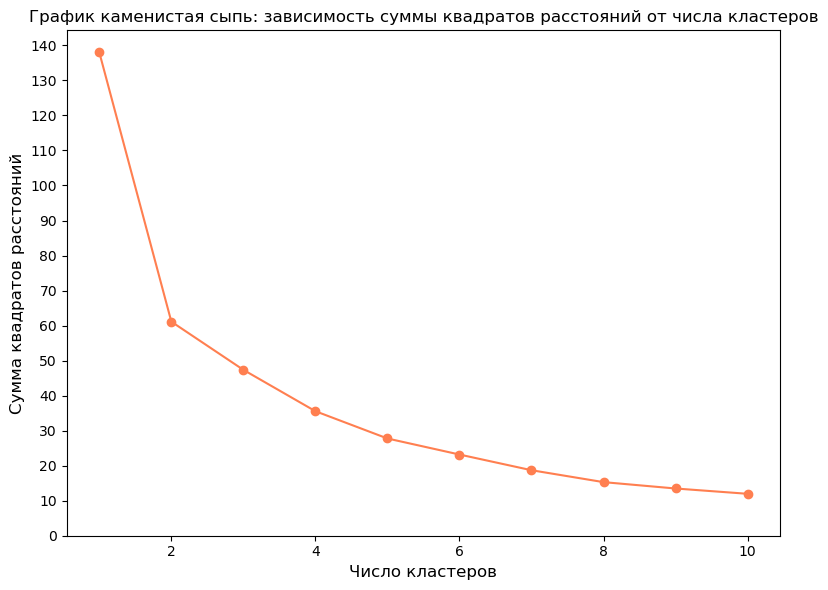

In [23]:
# Строим график каменистая осыпь

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(K, dist, marker='o', color="coral")
ax.set_yticks(range(0, 141, 10))
ax.set_xlabel('Число кластеров', fontsize=12)
ax.set_ylabel('Сумма квадратов расстояний', fontsize=12)
ax.set_title('График каменистая сыпь: зависимость суммы квадратов расстояний от числа кластеров', fontsize=12)

fig.tight_layout()
plt.show()

По графику «каменистая осыпь» было решено, что излом находится над числом 5.

In [25]:
print(f"Решено, что оптимальное число кластеров = {models[4].n_clusters}")
best_model = models[4]

Решено, что оптимальное число кластеров = 5


Можно также визуализировать разницу между суммой квадратов расстояний при переходе от k кластеров к k + 1 кластерам.

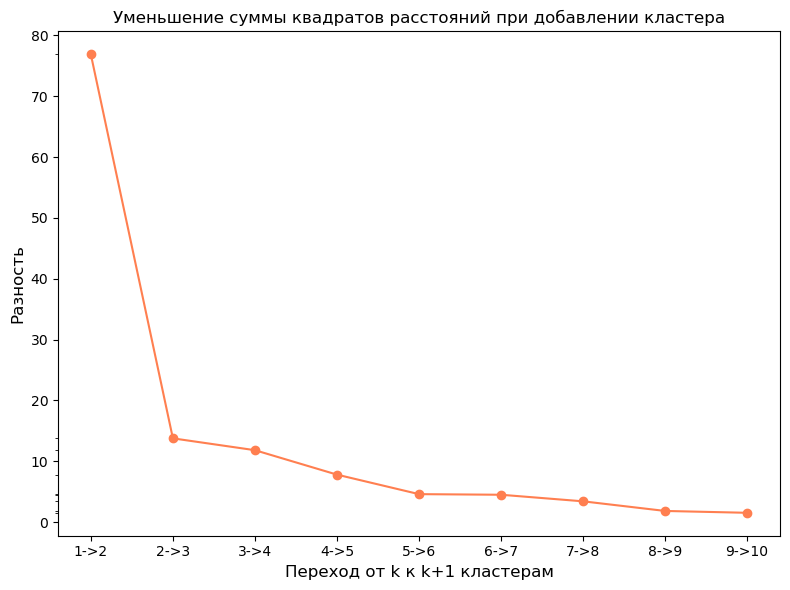

In [27]:
# Разность суммы квадратов расстояний при переходе от k кластеров к k + 1 кластеров
diff = np.array(dist[:-1]) - np.array(dist[1:])

# Строим график
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(range(1, 10), diff, marker='o', color="coral")
ax.set_xticks(range(1, 10))
ax.set_xticklabels(['1->2', '2->3', '3->4', '4->5', '5->6', '6->7', '7->8', '8->9', '9->10'])
ax.set_yticks(diff, minor=True)
ax.set_xlabel('Переход от k к k+1 кластерам', fontsize=12)
ax.set_ylabel('Разность', fontsize=12)
ax.set_title('Уменьшение суммы квадратов расстояний при добавлении кластера', fontsize=12)
plt.tight_layout()
plt.show()

#### Теперь посмотрим на получившиеся кластеры (всего 5 кластеров)

In [29]:
# К нашему датафрейму прибавим колонку cluster - какому clustery принадлежит наблюдение (город)
df["cluster"] = best_model.labels_

In [30]:
# Средние значения признаков в каждом кластере
df.groupby(by="cluster").mean()

,Work,Price,Salary
cluster,,,
0,1780.500000,108.550000,71.300000
1,1855.454545,50.781818,16.590909
2,1732.000000,78.135714,53.614286
3,2146.875000,48.762500,12.412500
4,1994.285714,75.814286,51.271429


### Теперь займемся анализом кластеров. 

**Кластер 0** - города, в которых самое низкое количество рабочих часов, самые высокие цены на товары и услуги, а также самые высокие средние зарплаты после налогов — это города из 3 скандинавских стран, Токио и 2 самых главных города Швейцарии — Цюрих и Женева. То есть в нулевом кластере находятся самые дорогие города из стран первого мира, довольно социальные (с небольшим количеством рабочих часов), не сугубо капиталистические (городов из США в этом кластере нет). Этот кластер полностью совпадает с кластером 1 из первой лабораторной на иерархический кластерный анализ, **когда мы взяли 5 кластеров**.

In [33]:
df[df["cluster"] == 0]

,Work,Price,Salary,cluster
City,,,,
Geneva,1880,95.9,90.3,0
Helsinki,1667,113.6,66.6,0
Oslo,1583,115.5,63.7,0
Stockholm,1805,111.3,39.2,0
Tokyo,1880,115.0,68.0,0
Zurich,1868,100.0,100.0,0


**Кластер 4** в городах из этого кластера работают больше, чем во всех остальных, кроме 3 кластера, при этом тут довольно высокие цены (выше только в кластере 0 и 2) и зарплаты, несмотря на то, что довольно высокие, сильно ниже, чем в 0 кластере. Это города США (сильно капиталистической страны) + Торонто из Канады, в которых люди работают очень много (выше только в городах из 3 кластера) - Чикаго, Хьюстон, Лос-Анджелес и Нью-Йорк, плюс в этом кластере находится Тайбей и Тель-Авив (в подобном кластере из лабы по иерархическому кластерному анализу (кластер номер 2 из лабы по иерархическому кластерному анализу (**случай 5 кластеров**)) были все те же города, кроме Тайбея и Тель-Авива — и это кажется правильным, учитывая низкую среднюю зарплату в них — 34,5 и 27,0).

In [35]:
df[df["cluster"] == 4]

,Work,Price,Salary,cluster
City,,,,
Chicago,1924,73.9,61.9,4
Houston,1978,71.9,46.3,4
Los_Angeles,2068,79.8,65.2,4
New_York,1942,83.3,65.8,4
Taipei,2145,84.3,34.5,4
Tel_Aviv,2015,67.3,27.0,4
Toronto,1888,70.2,58.2,4


**Кластер 2** - в городах этого кластера работают меньше всего среди всех кластеров, тут довольно высокие цены (хотя немногим выше, чем в 4 кластере) — выше только в 0 кластере, и высокие зарплаты - немного больше, чем в 4 кластере (хотя, конечно, они гораздо ниже, чем в 0 кластере). В основном это города крупных европейских стран - например, Dusseldorf и Frankfurt (Германия), Vienna (Австрия), Dublin (Ирландия), Copenhagen (Дания), Brussels (Бельгия), Amsterdam (Голландия) и т. п. Также есть Sydney (Австралия) и Montreal (Канада). То есть это кластер таких социальных, а не чисто капиталистических (как в кластере 4) городов из развитых стран (в основном Европы).

Этот кластер полностью совпадает с кластером номер 3 из лабы по иерархическому кластерному анализу (**случай 5 кластеров**).

In [37]:
df[df["cluster"] == 2]

,Work,Price,Salary,cluster
City,,,,
Amsterdam,1714,65.6,49.0,2
Brussels,1708,73.8,50.5,2
Copenhagen,1717,91.3,62.9,2
Dublin,1759,76.0,41.4,2
Dusseldorf,1693,78.5,60.2,2
Frankfurt,1650,74.5,60.4,2
London,1737,84.2,46.2,2
Luxembourg,1768,71.1,71.1,2
Madrid,1710,93.8,50.0,2


**Кластер 1** - в городах этого кластера достаточно много работают — больше, чем в городах из 2 и 0 кластеров, но всё же меньше, чем в городах из кластеров 3 и 4. Цены чуть выше, чем в кластере 3, но при этом сильно ниже, чем в кластерах 2 и 4, однако падение цен по сравнению с этими кластерами не такое сильное, как падение зарплат по сравнению с этими же кластерами (2 и 4). В этом кластере есть города из не самых богатых стран Европы — Athens (Греция), Lisbon (Португалия), Nicosia (Кипр), а также из развивающихся стран Buenos_Aires (Аргентина), Johannesburg (ЮАР), Mexico_City (Мексика) и т. д. Также в этом кластере есть города из развитых стран (но не из Европы) — Seoul (Южная Корея).

В подобном кластере из лабы по иерархическому кластерному анализу (номер 4) (**случай 5 кластеров**) не было городов Buenos_Aires, Johannesburg, Mexico_City, Nairobi — они были отнесены к другому кластеру.

In [39]:
df[df["cluster"] == 1]

,Work,Price,Salary,cluster
City,,,,
Athens,1792,53.8,30.4,1
Buenos_Aires,1971,56.1,12.5,1
Johannesburg,1945,51.1,24.0,1
Lagos,1786,45.2,2.7,1
Lisbon,1742,56.2,18.8,1
Mexico_City,1944,49.8,5.7,1
Nairobi,1958,45.0,5.8,1
Nicosia,1825,47.9,28.3,1
Rio_de_Janeiro,1749,46.3,10.5,1


**Кластер 3** - в этом кластере города, где работают ощутимо больше, чем во всех остальных кластерах, цены самые низкие (правда, лишь немного ниже, чем в кластере 1), а также самые низкие зарплаты (почти в 1,5 раза ниже, чем в кластере 1). В основном это города также из развивающихся стран — Bombay (Индия), Manila (Филиппины), Caracas (Венесуэла) и т. д. В этом кластере нет городов из Европы.

В подобном кластере (номер 5) из лабы по иерархическому кластерному анализу (**случай 5 кластеров**) были еще города Buenos_Aires, Johannesburg, Mexico_City, Nairobi, Taipei, Tel-Aviv — в этой лабораторной алгоритм KMeans отнес их к другим кластерам.

In [41]:
df[df["cluster"] == 3]

,Work,Price,Salary,cluster
City,,,,
Bogota,2152,37.9,11.5,3
Bombay,2052,30.3,5.3,3
Caracas,2041,61.0,10.9,3
Hong_Kong,2375,63.8,27.8,3
Kuala_Lumpur,2167,43.5,9.9,3
Manila,2268,40.0,4.0,3
Panama,2078,49.2,13.8,3
Singpore,2042,64.4,16.1,3
